In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [98]:
df = pd.read_csv('dados_processados.csv')


In [99]:
# Res: 'H' (casa vence), 'D' (empate), 'A' (fora vence)

df['target'] = df['Res'].map({'H': 0, 'D': 1, 'A': 2})
df['target_bin'] = (df['Res'] == 'H').astype(int) # target alternativa binaria


In [100]:
eps = 1e-6

# criando novas features para agregar prever o alvo
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + eps)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + eps)


# 1. Diferença de forma ofensiva (casa - fora)

In [101]:
df['diff_goals']       = df['home_last5_goals'] - df['away_last5_goals']
df['diff_winrate']     = df['home_last5_winrate'] - df['away_last5_winrate']
df['diff_ppg']         = df['home_last5_ppg'] - df['away_last5_ppg']

In [102]:
df['diff_goal_ratio_raw']   = df['home_goal_ratio'] - df['away_goal_ratio']
df['ratio_concede_raw']     = df['away_last5_concede'] / (df['home_last5_concede'] + eps)

In [103]:
# Capping percentis 1/99
for col in ['diff_goal_ratio_raw', 'ratio_concede_raw']:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col.replace('_raw', '_capped')] = df[col].clip(lo, hi)

In [104]:
# Log-transform para diff_goal_ratio
df['log_diff_goal_ratio'] = np.log1p(
    df['diff_goal_ratio_capped'] - df['diff_goal_ratio_capped'].min() + 0.01
)

In [105]:
form_prob = df["diff_winrate"] * 0.5 + 0.5

# Quem está mais otimista em relação ao mandante forma ou mercado
df["market_form_direction"] = (
    df["p_home"] - form_prob
)

# Quanto mercado e forma discordam
df["market_form_divergence"] = np.abs(
    df["p_home"] - form_prob
)

In [106]:
FEATURES_FINAIS = [
    # Mercado (2)
    'dif_prob', 'entropy',
    
    # Forma relativa — diferenças (3)
    'diff_goals', 'diff_winrate', 'diff_ppg',
    
    # Eficiência ofensiva (2)
    'home_goal_ratio', 'away_goal_ratio',
    
    # Vulnerabilidade relativa estabilizada (1)
    'ratio_concede_capped',
    
    # Interação mercado-forma (2) — NOVA
    #'market_form_divergence',
    "market_form_direction",
    
    # Eficiência relativa em log (1) — NOVA
    'log_diff_goal_ratio',
]

In [107]:
df_model = df[FEATURES_FINAIS + ['target_bin', 'Date_parsed']].dropna()
df_model = df_model.sort_values('Date_parsed').reset_index(drop=True)
print(f'Linhas para modelear: {len(df_model)}')


Linhas para modelear: 5222


# separando teste e treino

In [108]:
n = len(df_model)
cut = int( n * 0.8)

X_train = df_model.iloc[:cut][FEATURES_FINAIS]
X_test = df_model.iloc[cut:][FEATURES_FINAIS]
y_train = df_model.iloc[:cut]['target_bin']
y_test = df_model.iloc[cut:]['target_bin']

# TRATAR NAS DA TREINO E TESTE 

In [109]:
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# PERIODO TREINO

In [110]:
# periodo de treino
print(df_model.iloc[0]['Date_parsed'])
print(df_model.iloc[cut-1]['Date_parsed'])

2012-06-06
2023-05-11


# modelo baseline

In [111]:
from sklearn.dummy import DummyClassifier

bm = DummyClassifier()

bm.fit(X_train, y_train)
yp_dummy = bm.predict(X_test)
print(accuracy_score(y_test, yp_dummy))

0.5196172248803828


In [112]:
from sklearn.metrics import accuracy_score, classification_report, log_loss, brier_score_loss

In [113]:
#class_weight= {0: 0.5, 1: 1.25 , 2: 1.5}
rf = RandomForestClassifier(n_estimators=100, max_depth=10,class_weight= 'balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

pp_rf = rf.predict_proba(X_test)


print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf))
print(f"Brier:    {brier_score_loss(y_test, pp_rf[:,1]):.4f}")
print(f"LogLoss:  {log_loss(y_test, pp_rf):.4f}")


=== RANDOM FOREST ===
Accuracy: 0.6038
              precision    recall  f1-score   support

           0       0.63      0.57      0.60       543
           1       0.58      0.64      0.61       502

    accuracy                           0.60      1045
   macro avg       0.61      0.61      0.60      1045
weighted avg       0.61      0.60      0.60      1045

Brier:    0.2356
LogLoss:  0.6643


In [114]:
imp = pd.Series(rf.feature_importances_, index=FEATURES_FINAIS).sort_values(ascending=False)
print("\nFeature Importance:")
print(imp)



Feature Importance:
dif_prob                 0.216324
entropy                  0.146561
market_form_direction    0.118970
log_diff_goal_ratio      0.101639
away_goal_ratio          0.089536
ratio_concede_capped     0.089158
home_goal_ratio          0.085901
diff_goals               0.064980
diff_ppg                 0.058164
diff_winrate             0.028768
dtype: float64


Matriz de Confusão
A matriz de confusão é uma forma de visualizar o desempenho de um modelo de classificação. Cada linha representa as classes reais e cada coluna representa as classes previstas pelo modelo.

Verdadeiro Positivo (VP ou TP): casos em que o modelo previu corretamente a classe positiva.
Falso Positivo (FP): casos em que o modelo previu a classe positiva, mas a classe real era negativa.
Falso Negativo (FN): casos em que o modelo previu a classe negativa, mas a classe real era positiva.
Verdadeiro Negativo (VN ou TN): casos em que o modelo previu corretamente a classe negativa.
Olhe para a diagonal principal para ver os acertos; quanto mais concentrados estiverem os valores nela, mais preciso é o modelo.

📊 Explicação das Métricas de Classificação
Acurácia (accuracy_score): mede a proporção de previsões corretas (positivas e negativas) em relação ao total de amostras.
Fórmula: (VP + VN) / (VP + VN + FP + FN)

Boa quando as classes estão equilibradas.

Precisão (precision_score): indica, entre as previsões positivas do modelo, quantas realmente são positivas.
Fórmula: VP / (VP + FP)

Alta precisão = poucos falsos positivos.

Recall (recall_score): mostra, entre as amostras realmente positivas, quantas foram corretamente identificadas.
Fórmula: VP / (VP + FN)

Alto recall = poucos falsos negativos.

F1-score (f1_score): média harmônica entre Precisão e Recall, equilibrando as duas métricas.
Fórmula: 2 × (Precisão × Recall) / (Precisão + Recall)

Útil quando há desequilíbrio entre classes.

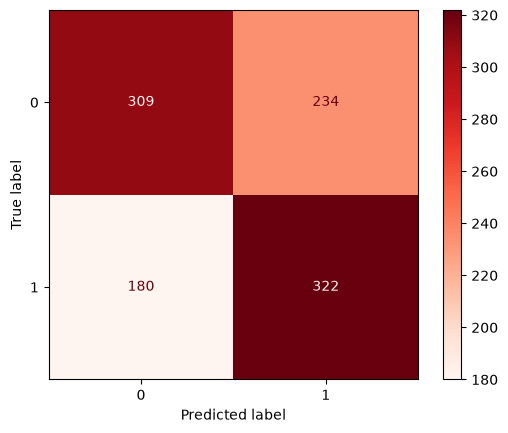

In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.show()